# 03 Mortality analysis

Descriptive mortality figures and the seasonal lag correlations.

| Output | Manuscript |
| --- | --- |
| `figures/figure_02_temporal_alignment.pdf` | Figure 2 |
| `figures/figure_03_national_livestock_population.pdf` | Figure 3 |
| `figures/figure_04_species_population_and_mortality.pdf` | Figure 4 |
| `figures/figure_06_seasonal_spei_correlations.pdf` | Figure 6 |
| `figures/figure_07_drought_and_species_mortality.pdf` | Figure 7 |
| printed tables | Tables S3, S7 |

Reads only `data/processed/`. No raw file is opened.

In [ ]:
import sys, os
from pathlib import Path

REPO = "mongolia-dzud-drought"
IN_COLAB = "google.colab" in sys.modules or Path("/content").exists()

if IN_COLAB and not Path(REPO).exists() and Path.cwd().name != REPO:
    !git clone -q https://github.com/nominkhurelchuluun/{REPO}.git /content/{REPO}
    os.chdir(f"/content/{REPO}")
elif Path.cwd().name == "notebooks":
    os.chdir("..")

sys.path.insert(0, str(Path.cwd()))

!pip install -q mapclassify

import numpy as np
import pandas as pd

from src import data_loading as dl
dl.describe_paths()

DATA_DIR      /content/mongolia-dzud-drought/data
RAW_DIR       /content/mongolia-dzud-drought/data/raw
PROCESSED_DIR /content/mongolia-dzud-drought/data/processed
FIG_DIR       /content/mongolia-dzud-drought/figures


In [ ]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from matplotlib.ticker import MultipleLocator
from scipy import stats

from src import data_loading as dl

dl.set_plot_style()
dl.describe_paths()

panel = dl.load_mortality_panel()
population_species = dl.load_population("national_species")
population_total = dl.load_population("national_total")
losses_annual = dl.load_losses("national_annual")
spei_seasonal = dl.load_spei("aimag_seasonal")

print(f"panel: {len(panel)} rows, {panel['Aimag'].nunique()} aimags, "
      f"{panel['Year'].min()}-{panel['Year'].max()}")

DATA_DIR      /content/mongolia-dzud-drought/data
RAW_DIR       /content/mongolia-dzud-drought/data/raw
PROCESSED_DIR /content/mongolia-dzud-drought/data/processed
FIG_DIR       /content/mongolia-dzud-drought/figures
panel: 693 rows, 21 aimags, 1992-2024


In [ ]:
mortality_by_year = (panel.groupby("Year", as_index=False)
                     [dl.SPECIES_COLS + ["All", "All_SFU"]].mean())
for column in dl.SPECIES_COLS + ["All", "All_SFU"]:
    mortality_by_year[column] = mortality_by_year[column] * 100

national_mortality = mortality_by_year.rename(
    columns={"All": "All_pct", "All_SFU": "All_SFU_pct"})

print(f"Mean aimag-mean SFU-weighted mortality, "
      f"{dl.MORT_START}-{dl.MORT_END}: "
      f"{national_mortality['All_SFU_pct'].mean():.2f}%")
print(f"Peak SFU-weighted mortality: "
      f"{national_mortality['All_SFU_pct'].max():.2f}% in "
      f"{int(national_mortality.loc[national_mortality['All_SFU_pct'].idxmax(), 'Year'])}")
print(national_mortality.round(2).to_string(index=False))

Mean aimag-mean SFU-weighted mortality, 1992-2024: 4.48%
Peak SFU-weighted mortality: 19.25% in 2010
 Year  Mort_hor  Mort_cat  Mort_cam  Mort_sheep  Mort_goat  All_pct  All_SFU_pct
 1992      3.47      4.19      4.92        3.82       2.70     3.80         3.84
 1993      6.25     10.08      5.25        6.23       4.55     6.47         7.22
 1994      2.29      3.60      3.87        4.19       2.85     3.35         3.31
 1995      2.38      2.97      2.77        3.78       2.58     2.92         2.97
 1996      2.15      2.66      6.63        2.61       1.91     3.16         2.42
 1997      1.90      3.85      1.67        2.69       1.99     2.46         2.69
 1998      2.08      3.38      1.36        2.38       2.23     2.29         2.51
 1999      2.23      3.50      1.47        2.19       1.91     2.26         2.45
 2000     10.39     16.56     12.17        7.68       7.66    10.89        10.51
 2001     15.26     31.41      5.54       14.31      12.50    15.80        18.96
 2002   

## Figure 2. Temporal alignment

A schematic with no data dependency. It documents how JJA SPEI-3 in year t-1, the
December t-1 population, the DJF t temperature Z-score and calendar-year deaths in
year t combine into the annual mortality rate.

saved /content/mongolia-dzud-drought/figures/figure_02_temporal_alignment.pdf  (170 x 72 mm at print size)


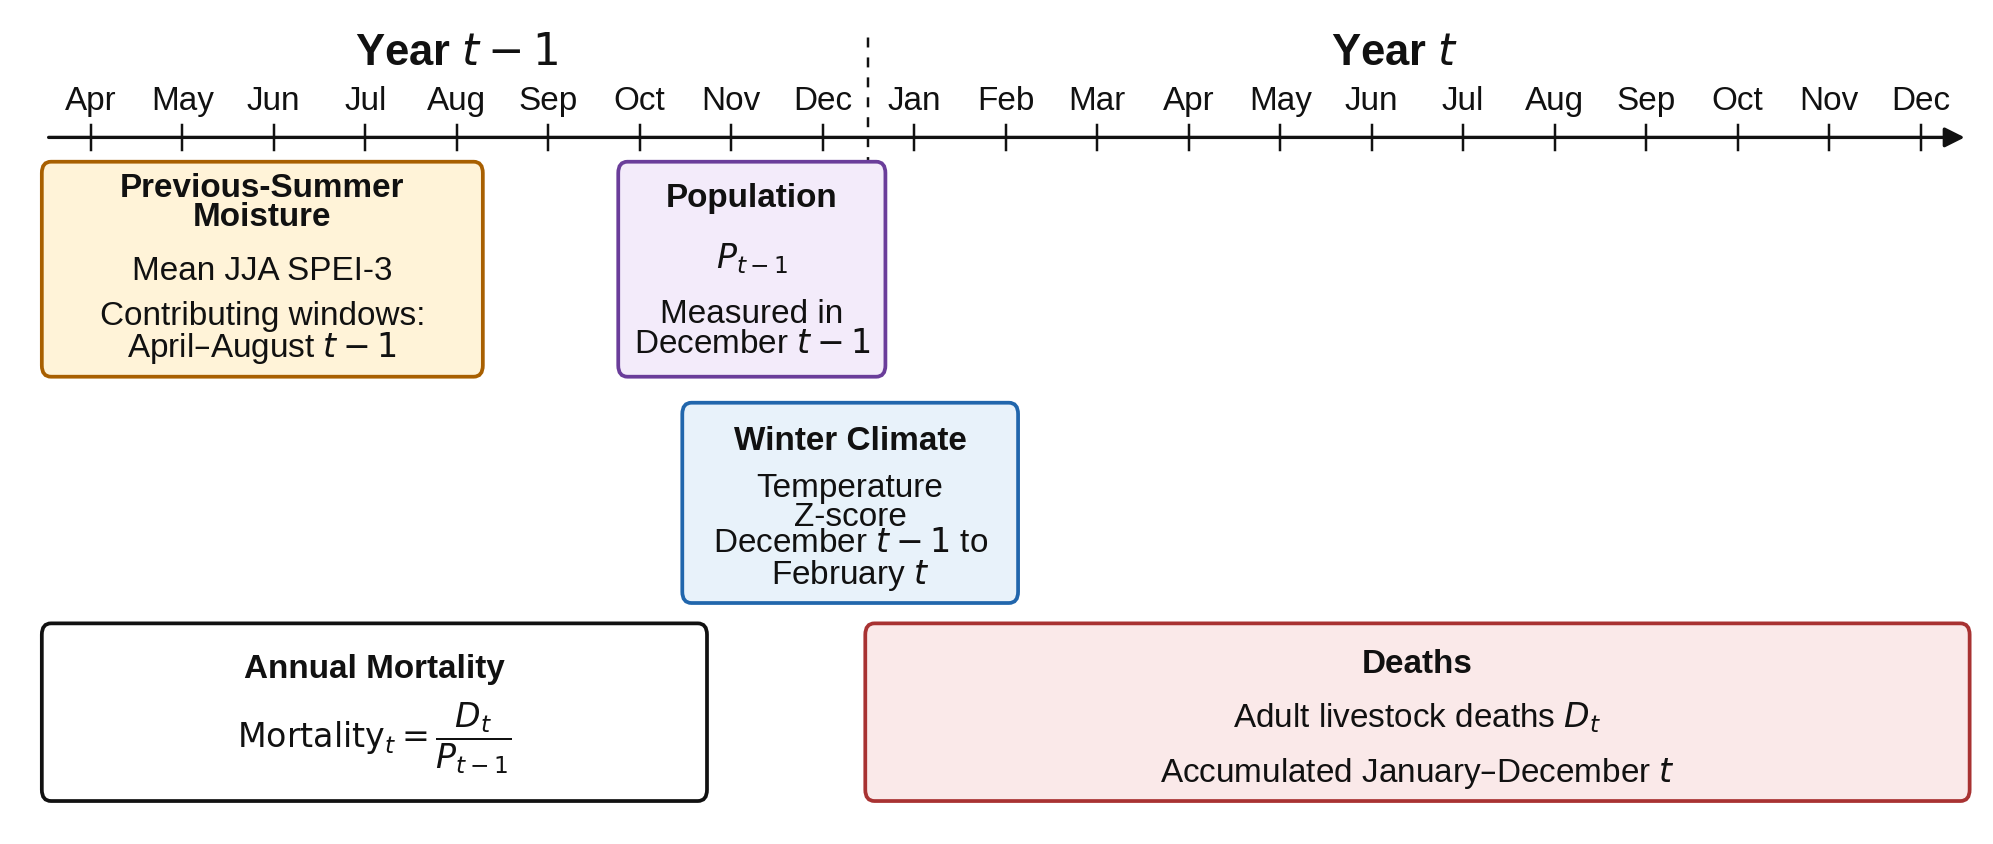

In [ ]:
SCHEMATIC_SCALE = 2.3


def draw_temporal_alignment(ax, panel_label=None):
    black = "#111111"
    orange, orange_fill = "#A85F00", "#FFF3D8"
    purple, purple_fill = "#6A3D9A", "#F3EBFA"
    blue, blue_fill = "#2166AC", "#E8F2FA"
    red, red_fill = "#A83232", "#FAE9E9"

    body = 8.0 * SCHEMATIC_SCALE

    ax.set_xlim(-0.85, 20.65)
    ax.set_ylim(0.25, 7.48)
    ax.axis("off")

    def card(x, y, width, height, facecolor, edgecolor, header, title, subtitle="",
             header_y=0.80, title_y=0.49, subtitle_y=0.15):
        ax.add_patch(FancyBboxPatch(
            (x, y), width, height,
            boxstyle="round,pad=0.035,rounding_size=0.10",
            facecolor=facecolor, edgecolor=edgecolor,
            linewidth=0.9 * SCHEMATIC_SCALE, zorder=2))
        ax.text(x + width / 2, y + height * header_y, header, ha="center",
                va="center", fontsize=body, fontweight="bold", color=black,
                linespacing=0.95, zorder=3)
        ax.text(x + width / 2, y + height * title_y, title, ha="center", va="center",
                fontsize=body, color=black, linespacing=0.95, zorder=3)
        if subtitle:
            ax.text(x + width / 2, y + height * subtitle_y, subtitle, ha="center",
                    va="center", fontsize=body, color=black, linespacing=0.95,
                    zorder=3)

    months = ["Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
              "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep",
              "Oct", "Nov", "Dec"]

    timeline_y = 6.38
    boundary_x = 8.5

    ax.add_patch(FancyArrowPatch((-0.50, timeline_y), (20.52, timeline_y),
                                 arrowstyle="-|>", mutation_scale=10 * SCHEMATIC_SCALE,
                                 linewidth=0.8 * SCHEMATIC_SCALE, color=black, zorder=1))

    for x, month in enumerate(months):
        ax.plot([x, x], [timeline_y - 0.11, timeline_y + 0.11], color=black,
                linewidth=0.6 * SCHEMATIC_SCALE, zorder=2)
        ax.text(x, timeline_y + 0.18, month, ha="center", va="bottom",
                fontsize=8.0 * SCHEMATIC_SCALE, color=black, zorder=3)

    ax.plot([boundary_x, boundary_x], [5.94, 7.31], linestyle=(0, (4, 4)),
            color=black, linewidth=0.6 * SCHEMATIC_SCALE, zorder=1)

    ax.text(4.0, 7.12, r"Year $t-1$", ha="center", va="center",
            fontsize=10.5 * SCHEMATIC_SCALE, fontweight="bold", color=black)
    ax.text(14.25, 7.12, r"Year $t$", ha="center", va="center",
            fontsize=10.5 * SCHEMATIC_SCALE, fontweight="bold", color=black)

    card(x=-0.50, y=4.30, width=4.75, height=1.83,
         facecolor=orange_fill, edgecolor=orange,
         header="Previous-Summer\nMoisture",
         title="Mean JJA SPEI-3",
         subtitle="Contributing windows:\nApril\u2013August $t-1$",
         header_y=0.82, title_y=0.49, subtitle_y=0.19)

    card(x=5.8, y=4.30, width=2.85, height=1.83,
         facecolor=purple_fill, edgecolor=purple,
         header="Population", title=r"$P_{t-1}$",
         subtitle="Measured in\n" + r"December $t-1$",
         header_y=0.84, title_y=0.55, subtitle_y=0.21)

    card(x=6.50, y=2.30, width=3.60, height=1.70,
         facecolor=blue_fill, edgecolor=blue,
         header="Winter Climate", title="Temperature\nZ-score",
         subtitle=r"December $t-1$ to" + "\n" + r"February $t$",
         header_y=0.82, title_y=0.50, subtitle_y=0.20)

    card(x=-0.50, y=0.55, width=7.20, height=1.50,
         facecolor="white", edgecolor=black,
         header="Annual Mortality",
         title=r"$\mathrm{Mortality}_{t}=\dfrac{D_t}{P_{t-1}}$",
         header_y=0.75, title_y=0.35)

    card(x=8.50, y=0.55, width=12.00, height=1.50,
         facecolor=red_fill, edgecolor=red,
         header="Deaths", title=r"Adult livestock deaths $D_t$",
         subtitle="Accumulated January\u2013December $t$",
         header_y=0.78, title_y=0.47, subtitle_y=0.14)

    if panel_label:
        ax.text(-0.78, 7.38, f"({panel_label})", ha="left", va="top",
                fontsize=11 * SCHEMATIC_SCALE, fontweight="bold", color=black)

    return ax


fig, ax = plt.subplots(
    figsize=(dl.AGU_MAX_WIDTH_IN * SCHEMATIC_SCALE, 2.85 * SCHEMATIC_SCALE),
    facecolor="white")
draw_temporal_alignment(ax)
fig.subplots_adjust(left=0.012, right=0.995, top=0.985, bottom=0.025)
dl.save_figure(fig, "figure_02_temporal_alignment", scale=SCHEMATIC_SCALE)
plt.show()

## Figure 3. National livestock population, 1970-2024

saved /content/mongolia-dzud-drought/figures/figure_03_national_livestock_population.pdf  (170 x 79 mm at print size)


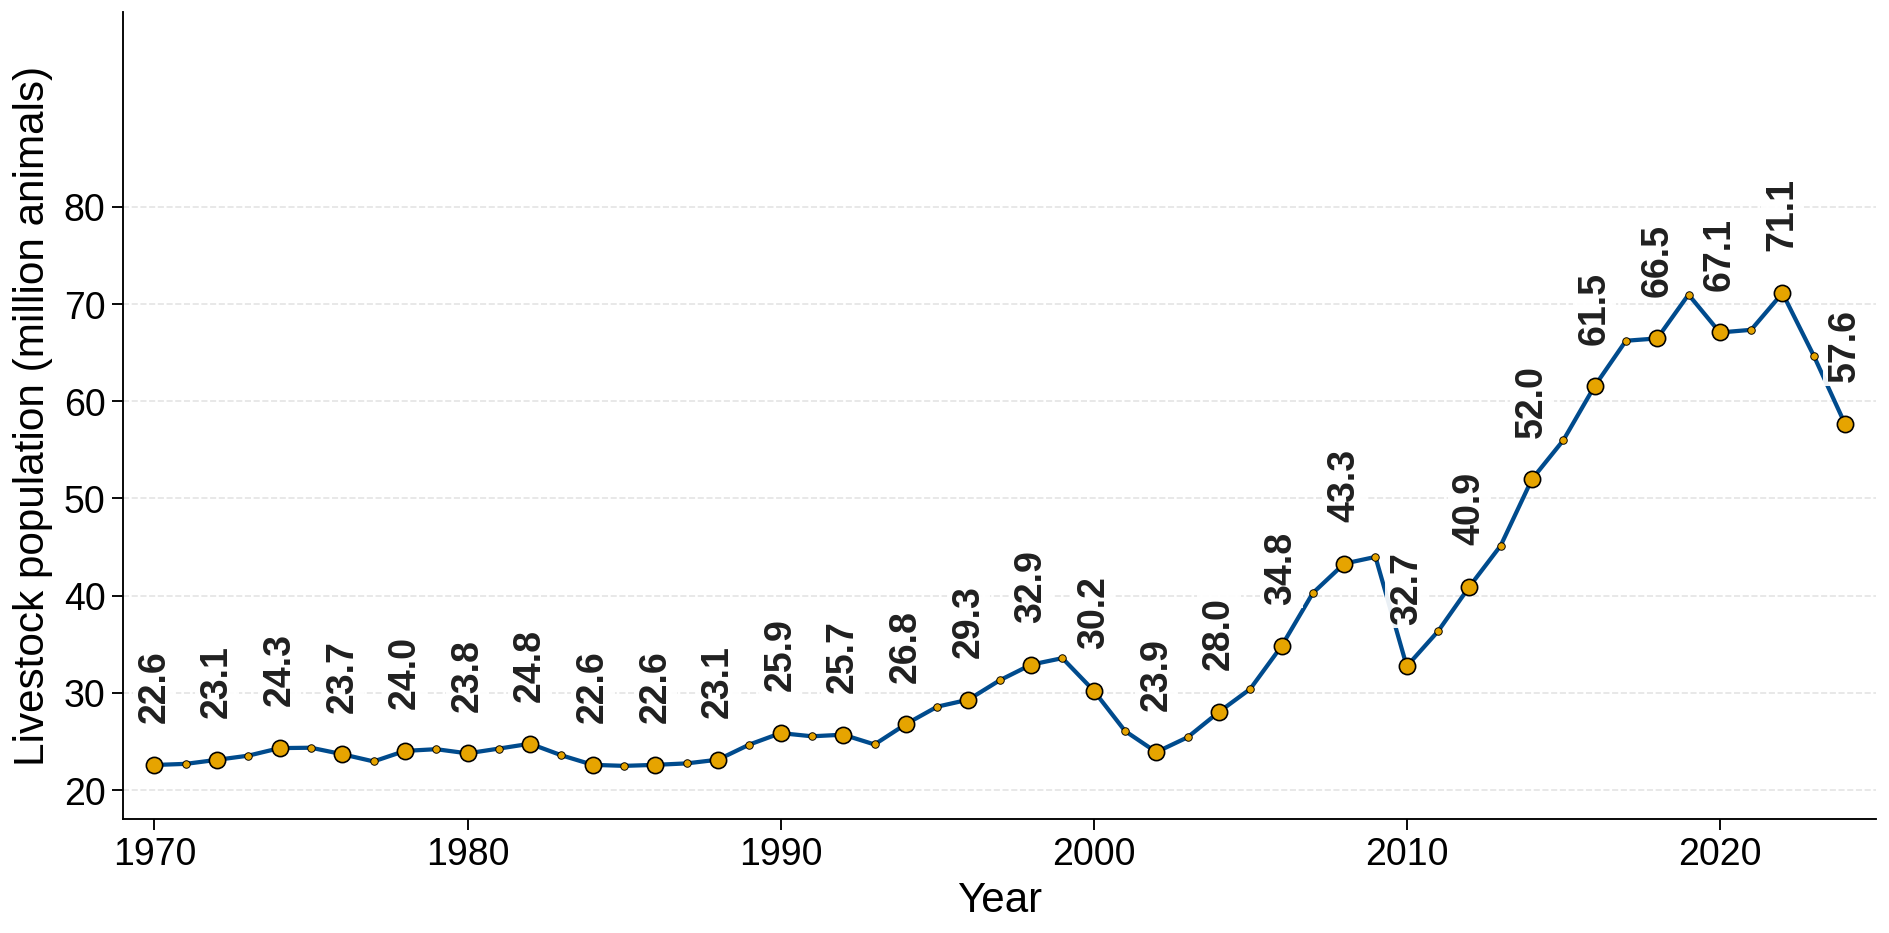

Peak national herd 71.1 M in 2022
Largest year-over-year declines
 Year  Population_millions  Change_millions  Change_percent
 2010                32.73           -11.25          -25.58
 2001                26.08            -4.15          -13.74
 2024                57.65            -7.03          -10.87
 2000                30.23            -3.34           -9.95
 2023                64.68            -6.44           -9.05


In [ ]:
POP_SCALE = 2.6
LABEL_YEARS = list(range(1970, 2025, 2))
LABEL_X_OFFSETS = {}

with mpl.rc_context({"font.size": 8 * POP_SCALE,
                     "axes.labelsize": 9 * POP_SCALE,
                     "xtick.labelsize": 8 * POP_SCALE,
                     "ytick.labelsize": 8 * POP_SCALE,
                     "axes.linewidth": 0.4 * POP_SCALE,
                     "pdf.fonttype": 42, "ps.fonttype": 42}):

    fig, ax = plt.subplots(
        figsize=(dl.AGU_MAX_WIDTH_IN * POP_SCALE, 3.1 * POP_SCALE),
        facecolor="white")

    ax.plot(population_total["Year"], population_total["Population_millions"],
            color="#004B8D", linewidth=0.9 * POP_SCALE, marker="o",
            markersize=1.6 * POP_SCALE, markerfacecolor="#E6A400",
            markeredgecolor="black", markeredgewidth=0.2 * POP_SCALE, zorder=3)

    highlighted = population_total[population_total["Year"].isin(LABEL_YEARS)]
    ax.scatter(highlighted["Year"], highlighted["Population_millions"],
               s=12 * POP_SCALE ** 2, color="#E6A400", edgecolor="black",
               linewidth=0.35 * POP_SCALE, zorder=5)

    for row in highlighted.itertuples():
        ax.annotate(f"{row.Population_millions:.1f}",
                    xy=(row.Year, row.Population_millions),
                    xytext=(LABEL_X_OFFSETS.get(int(row.Year), 0), 9 * POP_SCALE),
                    textcoords="offset points", ha="center", va="bottom",
                    rotation=90, fontsize=8 * POP_SCALE, fontweight="bold",
                    color="#202020",
                    bbox={"boxstyle": "square,pad=0.10", "facecolor": "white",
                          "edgecolor": "none", "alpha": 0.92},
                    annotation_clip=False, zorder=8)

    ax.set_xlabel("Year", fontsize=9 * POP_SCALE, labelpad=4)
    ax.set_ylabel("Livestock population (million animals)",
                  fontsize=9 * POP_SCALE, labelpad=6)
    ax.set_xlim(1969, 2025)
    ax.set_xticks(np.arange(1970, 2025, 10))
    ax.set_ylim(17, 100)
    ax.set_yticks(np.arange(20, 81, 10))
    ax.tick_params(axis="both", labelsize=8 * POP_SCALE,
                   width=0.4 * POP_SCALE, length=2.4 * POP_SCALE)
    ax.grid(axis="y", linestyle="--", linewidth=0.35 * POP_SCALE, alpha=0.35)
    ax.grid(axis="x", visible=False)
    ax.spines[["top", "right"]].set_visible(False)

dl.save_figure(fig, "figure_03_national_livestock_population", scale=POP_SCALE)
plt.show()

peak_year = int(population_total.loc[
    population_total["Population_millions"].idxmax(), "Year"])
print(f"Peak national herd {population_total['Population_millions'].max():.1f} M "
      f"in {peak_year}")
print("Largest year-over-year declines")
print(population_total.nsmallest(5, "Change_percent")
      [["Year", "Population_millions", "Change_millions", "Change_percent"]]
      .round(2).to_string(index=False))

## Figure 4. Species populations and species mortality rates

saved /content/mongolia-dzud-drought/figures/figure_04_species_population_and_mortality.pdf  (170 x 67 mm at print size)


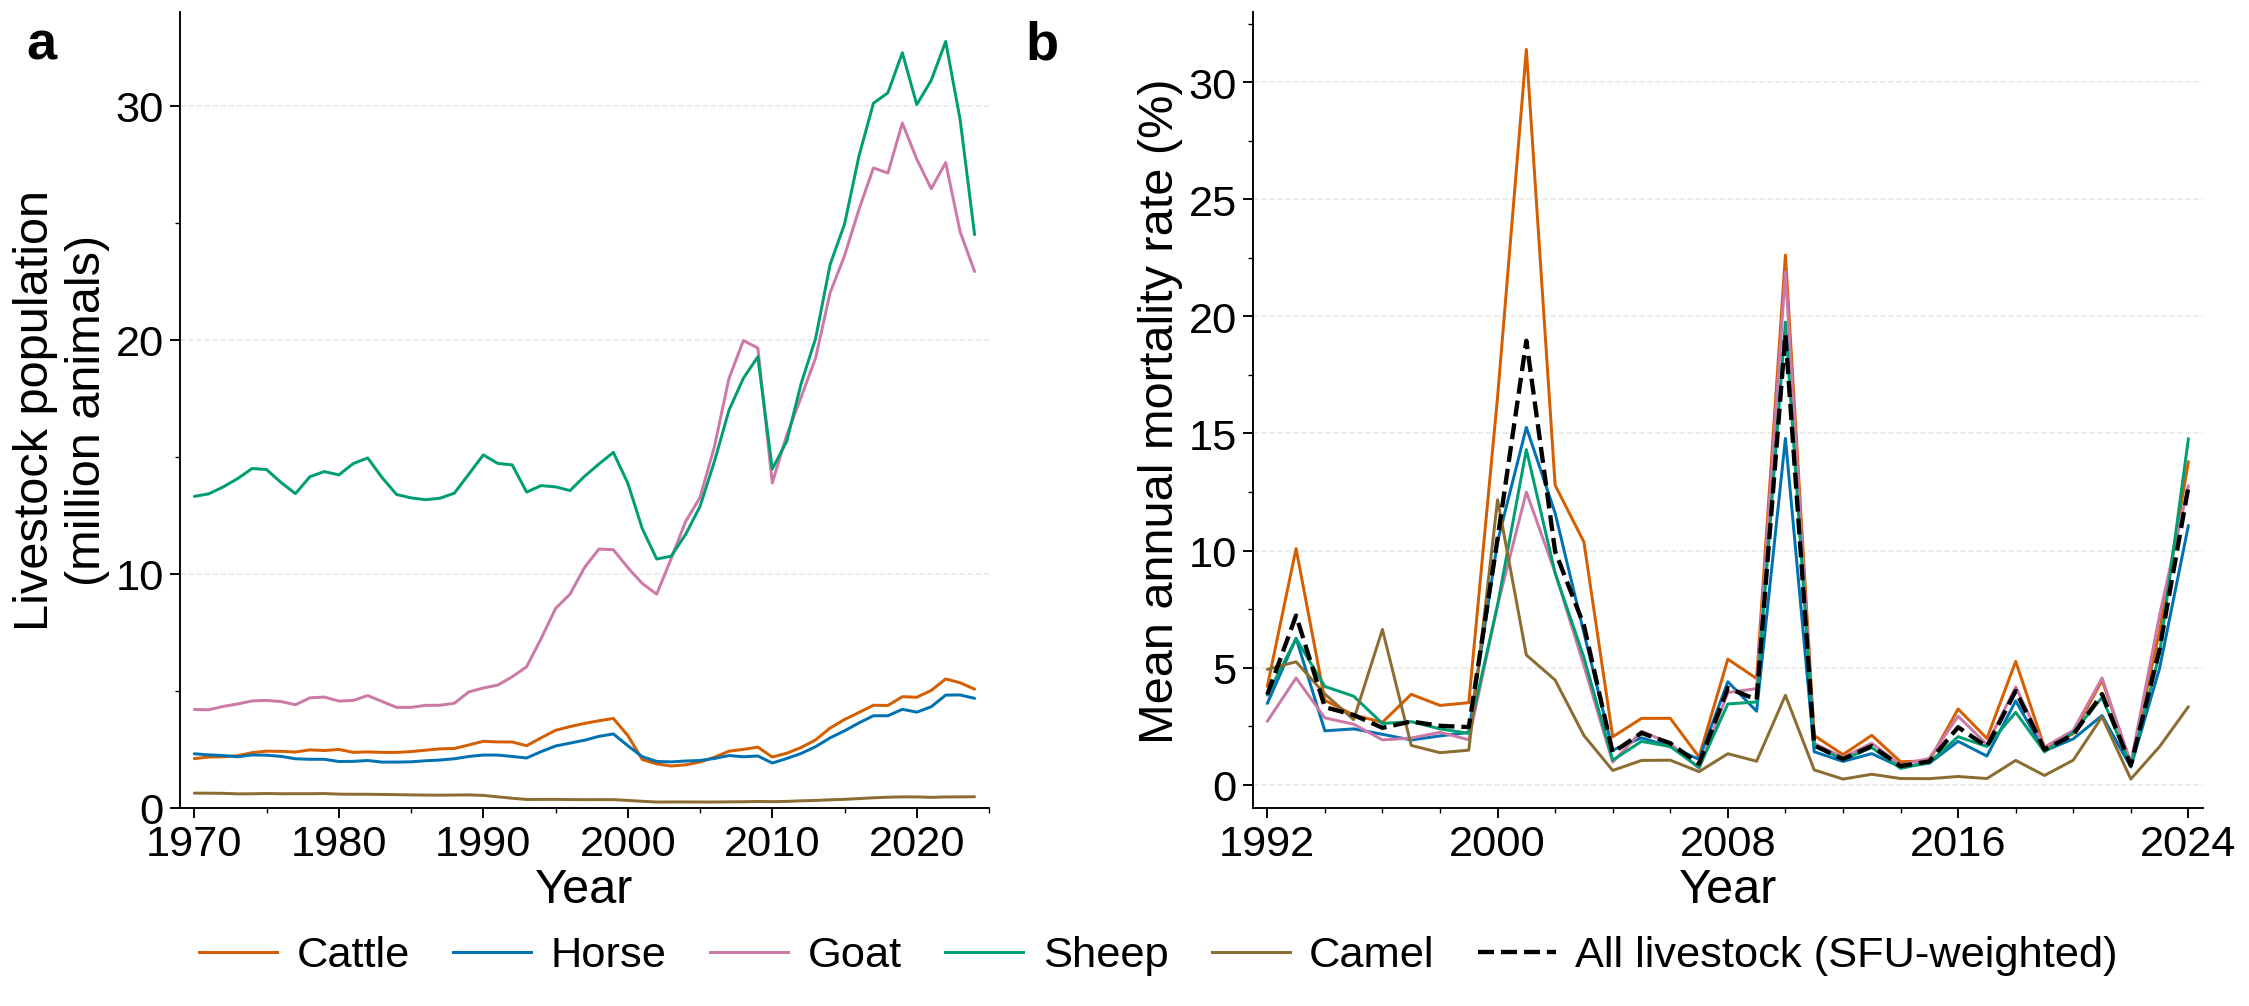

Headcount 22.6 M -> 57.6 M (x2.55)
SFU units 49.1 -> 110.8 (x2.25)
Goat share of headcount 18.6% -> 39.8%


In [ ]:
FIG4_SCALE = 3.0
SPECIES_ORDER = ["Mort_cat", "Mort_hor", "Mort_goat", "Mort_sheep", "Mort_cam"]
POP_COLUMN = {"Mort_cat": "Cattle", "Mort_hor": "Horse", "Mort_goat": "Goat",
              "Mort_sheep": "Sheep", "Mort_cam": "Camel"}

with mpl.rc_context({"font.size": 8 * FIG4_SCALE,
                     "axes.labelsize": 9 * FIG4_SCALE,
                     "xtick.labelsize": 8 * FIG4_SCALE,
                     "ytick.labelsize": 8 * FIG4_SCALE,
                     "legend.fontsize": 8 * FIG4_SCALE,
                     "axes.linewidth": 0.35 * FIG4_SCALE,
                     "pdf.fonttype": 42, "ps.fonttype": 42}):

    fig, (ax_a, ax_b) = plt.subplots(
        nrows=1, ncols=2,
        figsize=(dl.AGU_MAX_WIDTH_IN * FIG4_SCALE, 2.65 * FIG4_SCALE),
        gridspec_kw={"width_ratios": [0.92, 1.08], "wspace": 0.30},
        facecolor="white")

    for key in SPECIES_ORDER:
        ax_a.plot(population_species["Year"], population_species[POP_COLUMN[key]],
                  color=dl.SPECIES_COLORS[key], linewidth=0.55 * FIG4_SCALE,
                  solid_capstyle="round", zorder=4)

    ax_a.set_ylabel("Livestock population\n(million animals)",
                    fontsize=9 * FIG4_SCALE, labelpad=3)
    ax_a.set_xlabel("Year", fontsize=9 * FIG4_SCALE, labelpad=2)
    ax_a.set_xlim(1969, 2025)
    ax_a.set_xticks(np.arange(1970, 2025, 10))
    ax_a.set_ylim(0, 34)
    ax_a.set_yticks(np.arange(0, 31, 10))
    ax_a.yaxis.set_minor_locator(MultipleLocator(5))
    ax_a.xaxis.set_minor_locator(MultipleLocator(5))

    for key in SPECIES_ORDER:
        ax_b.plot(national_mortality["Year"], national_mortality[key],
                  color=dl.SPECIES_COLORS[key], linewidth=0.55 * FIG4_SCALE,
                  solid_capstyle="round", zorder=3)
    ax_b.plot(national_mortality["Year"], national_mortality["All_SFU_pct"],
              color="black", linestyle="--", linewidth=0.8 * FIG4_SCALE, zorder=10)

    ax_b.set_ylabel("Mean annual mortality rate (%)",
                    fontsize=9 * FIG4_SCALE, labelpad=3)
    ax_b.set_xlabel("Year", fontsize=9 * FIG4_SCALE, labelpad=2)
    ax_b.set_xlim(1991.5, 2024.5)
    ax_b.set_xticks(np.arange(1992, 2025, 8))
    ax_b.set_ylim(-1.0, 33)
    ax_b.set_yticks(np.arange(0, 31, 5))
    ax_b.xaxis.set_minor_locator(MultipleLocator(2))
    ax_b.yaxis.set_minor_locator(MultipleLocator(2.5))

    for axis, letter, offset in [(ax_a, "a", -0.19), (ax_b, "b", -0.24)]:
        axis.grid(axis="y", linestyle="--", linewidth=0.28 * FIG4_SCALE, alpha=0.30)
        axis.grid(axis="x", visible=False)
        axis.set_axisbelow(True)
        axis.spines[["top", "right"]].set_visible(False)
        axis.tick_params(axis="both", which="major", direction="out",
                         labelsize=8 * FIG4_SCALE, width=0.35 * FIG4_SCALE,
                         length=1.8 * FIG4_SCALE)
        axis.tick_params(axis="both", which="minor", direction="out",
                         width=0.25 * FIG4_SCALE, length=1.0 * FIG4_SCALE)
        axis.text(offset, 0.99, letter, transform=axis.transAxes,
                  fontsize=10 * FIG4_SCALE, fontweight="bold", ha="left", va="top")

    handles = [Line2D([], [], color=dl.SPECIES_COLORS[k],
                      linewidth=0.55 * FIG4_SCALE, label=dl.SPECIES_LABELS[k])
               for k in SPECIES_ORDER]
    handles.append(Line2D([], [], color="black", linestyle="--",
                          linewidth=0.8 * FIG4_SCALE,
                          label="All livestock (SFU-weighted)"))
    fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.09),
               ncol=6, fontsize=8 * FIG4_SCALE, frameon=False, handlelength=1.8,
               handletextpad=0.45, columnspacing=1.0)

dl.save_figure(fig, "figure_04_species_population_and_mortality", scale=FIG4_SCALE)
plt.show()

first_year = int(population_species["Year"].min())
last_year = int(population_species["Year"].max())
first_row = population_species.set_index("Year").loc[first_year]
last_row = population_species.set_index("Year").loc[last_year]
print(f"Headcount {first_row['Headcount']:.1f} M -> {last_row['Headcount']:.1f} M "
      f"(x{last_row['Headcount'] / first_row['Headcount']:.2f})")
print(f"SFU units {first_row['SFU_units']:.1f} -> {last_row['SFU_units']:.1f} "
      f"(x{last_row['SFU_units'] / first_row['SFU_units']:.2f})")
print(f"Goat share of headcount "
      f"{first_row['Goat'] / first_row['Headcount'] * 100:.1f}% -> "
      f"{last_row['Goat'] / last_row['Headcount'] * 100:.1f}%")

## Figure 6 and Table S3. Seasonal SPEI-3 in year t-1 against mortality in year t

National annual series are formed by averaging the area-weighted aimag values, then
correlated with the aimag-mean annual mortality rate in the following year.

In [ ]:
aimag_area = (pd.read_csv(dl.processed_path("spei3_cell_area_weights.csv"))
              .groupby("Aimag", as_index=False)["weight"].sum()
              .rename(columns={"weight": "Area"}))

seasonal_national = (spei_seasonal.merge(aimag_area, on="Aimag", how="inner")
                     .assign(wx=lambda d: d["Seasonal_SPEI3"] * d["Area"])
                     .groupby(["Year", "Season"], as_index=False)
                     .agg(num=("wx", "sum"), den=("Area", "sum"))
                     .assign(Seasonal_SPEI3=lambda d: d["num"] / d["den"])
                     .drop(columns=["num", "den"]))

check = (seasonal_national[seasonal_national["Season"].eq("JJA")]
         .merge(dl.load_spei("national_jja"), on="Year"))
print("JJA seasonal series vs the Figure 5 national series: "
      f"max difference {abs(check['Seasonal_SPEI3'] - check['JJA_Mean_SPEI3']).max():.4f}")

annual_mortality = national_mortality[["Year", "All_pct"]].copy()

SEASONS = [("Winter\n(DJF)", "DJF"), ("Spring\n(MAM)", "MAM"),
           ("Summer\n(JJA)", "JJA"), ("Autumn\n(SON)", "SON")]
SEASON_COLORS = [dl.OKABE_ITO["sky_blue"], dl.OKABE_ITO["bluish_green"],
                 dl.OKABE_ITO["orange"], dl.OKABE_ITO["vermillion"]]

correlations = []
for label, code in SEASONS:
    lagged = (seasonal_national[seasonal_national["Season"].eq(code)]
              .assign(Year=lambda d: d["Year"] + 1)
              [["Year", "Seasonal_SPEI3"]])
    merged = annual_mortality.merge(lagged, on="Year").dropna()
    fit = stats.linregress(merged["Seasonal_SPEI3"], merged["All_pct"])
    correlations.append({"Season": label.replace("\n", " "), "Code": code,
                         "r": fit.rvalue, "p_value": fit.pvalue,
                         "n": len(merged)})

table_s3 = pd.DataFrame(correlations)
print("Table S3. Lagged seasonal correlations with year-t annual mortality")
print(table_s3.round(3).to_string(index=False))

JJA seasonal series vs the Figure 5 national series: max difference 0.0000
Table S3. Lagged seasonal correlations with year-t annual mortality
      Season Code      r  p_value  n
Winter (DJF)  DJF -0.117    0.518 33
Spring (MAM)  MAM -0.036    0.843 33
Summer (JJA)  JJA -0.298    0.093 33
Autumn (SON)  SON -0.090    0.620 33


saved /content/mongolia-dzud-drought/figures/figure_06_seasonal_spei_correlations.pdf  (170 x 99 mm at print size)


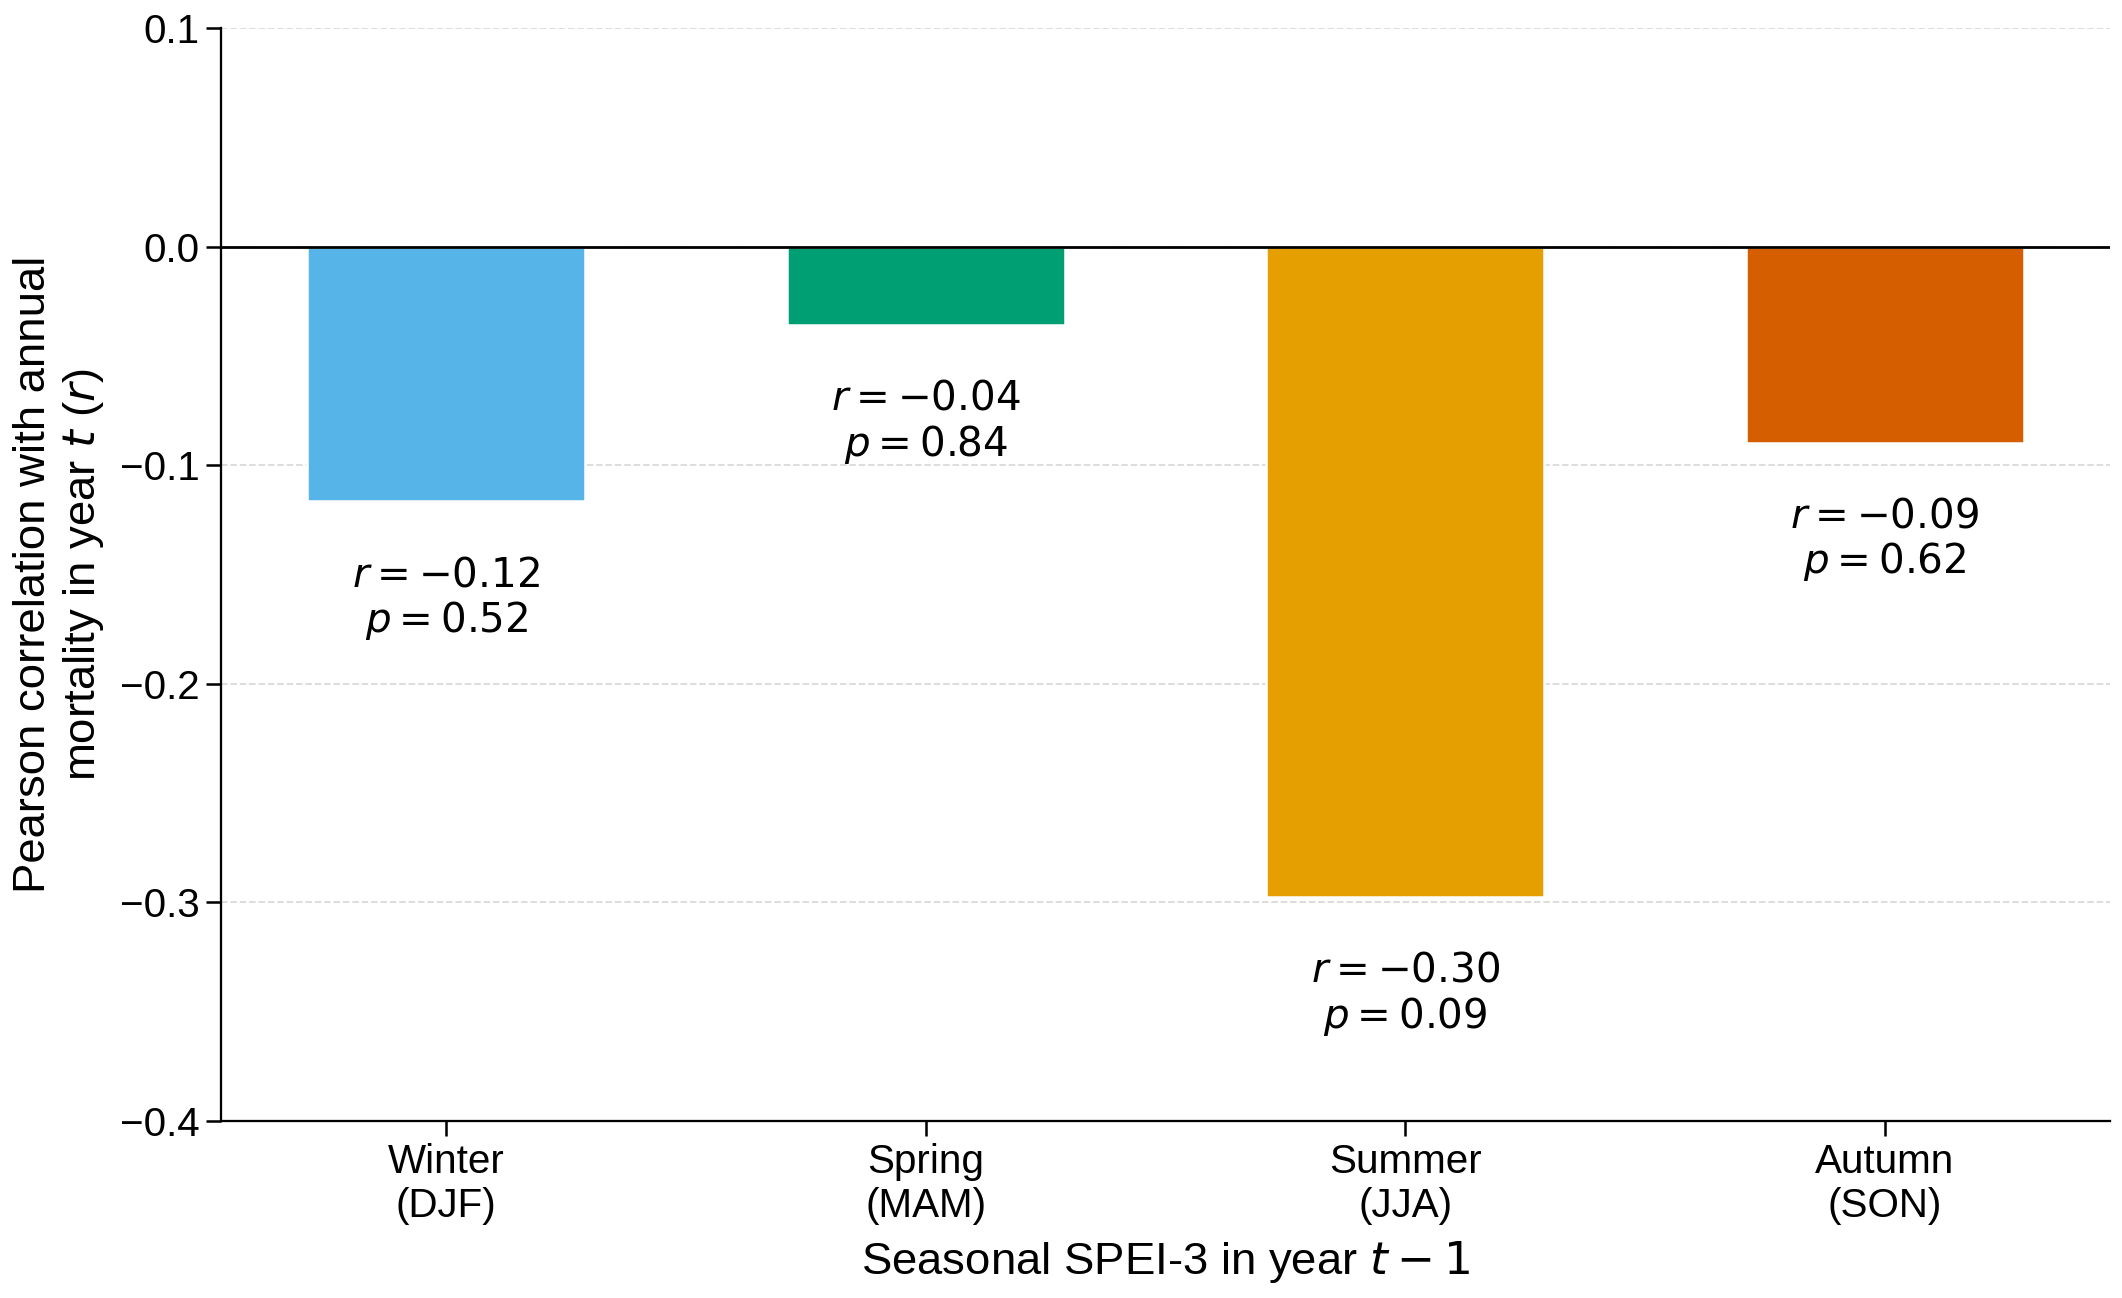

In [ ]:
FIG6_SCALE = 2.8

with mpl.rc_context({"font.size": 8 * FIG6_SCALE,
                     "axes.labelsize": 9 * FIG6_SCALE,
                     "xtick.labelsize": 8 * FIG6_SCALE,
                     "ytick.labelsize": 8 * FIG6_SCALE,
                     "axes.linewidth": 0.45 * FIG6_SCALE,
                     "pdf.fonttype": 42, "ps.fonttype": 42}):

    fig, ax = plt.subplots(
        figsize=(dl.AGU_MAX_WIDTH_IN * FIG6_SCALE, 3.9 * FIG6_SCALE),
        facecolor="white")

    positions = np.arange(len(SEASONS))
    bars = ax.bar(positions, table_s3["r"], width=0.58, color=SEASON_COLORS,
                  edgecolor="white", linewidth=0.5 * FIG6_SCALE, zorder=3)

    for bar, row in zip(bars, table_s3.itertuples()):
        p_text = "$p<0.001$" if row.p_value < 0.001 else f"$p={row.p_value:.2f}$"
        offset = -0.025 if row.r < 0 else 0.025
        ax.text(bar.get_x() + bar.get_width() / 2, row.r + offset,
                f"$r={row.r:.2f}$\n{p_text}", ha="center",
                va="top" if row.r < 0 else "bottom",
                fontsize=8 * FIG6_SCALE, color="black", linespacing=1.15,
                zorder=5, clip_on=False)

    ax.axhline(0, color="black", linewidth=0.55 * FIG6_SCALE, zorder=4)
    ax.set_xticks(positions, [label for label, _ in SEASONS])
    ax.set_xlabel("Seasonal SPEI-3 in year $t-1$", fontsize=9 * FIG6_SCALE, labelpad=8)
    ax.set_ylabel("Pearson correlation with annual\nmortality in year $t$ ($r$)",
                  fontsize=9 * FIG6_SCALE, labelpad=8)
    ax.set_ylim(-0.4, 0.1)
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.tick_params(axis="both", which="major", labelsize=8 * FIG6_SCALE,
                   width=0.5 * FIG6_SCALE, length=3 * FIG6_SCALE, direction="out")
    ax.set_axisbelow(True)
    ax.grid(axis="y", linestyle="--", linewidth=0.35 * FIG6_SCALE,
            color="#A0A0A0", alpha=0.40, zorder=0)
    ax.grid(axis="x", visible=False)
    ax.spines[["top", "right"]].set_visible(False)

dl.save_figure(fig, "figure_06_seasonal_spei_correlations", scale=FIG6_SCALE)
plt.show()

## Figure 7 and Table S7. Dry summers and species mortality

Panels (a) and (b) compare mean annual mortality after dry summers with mean annual
mortality after normal or wet summers. Panel (c) regresses each species rate on
previous-summer SPEI-3 across all aimag-years.

`AGGREGATE_COL` selects the panel (a) aggregate. `All` is the unweighted mean of the
five species rates and reproduces the submitted figure. `All_SFU` is the Equation (2)
rate. Both are printed below so the caption can be matched to the code.

In [ ]:
AGGREGATE_COL = "All"

plot_panel = panel.dropna(subset=["SPEI_PrevSummer"]).copy()
plot_panel["Dry_PrevSummer"] = plot_panel["SPEI_PrevSummer"] < dl.DRY_THRESHOLD

for column in ("All", "All_SFU"):
    dry = plot_panel.loc[plot_panel["Dry_PrevSummer"], column].dropna() * 100
    normal = plot_panel.loc[~plot_panel["Dry_PrevSummer"], column].dropna() * 100
    print(f"{column:8s} normal/wet {normal.mean():5.2f}%  "
          f"dry {dry.mean():5.2f}%  difference {dry.mean() - normal.mean():+.2f} pp")

aggregate_normal = (plot_panel.loc[~plot_panel["Dry_PrevSummer"], AGGREGATE_COL]
                    .dropna() * 100)
aggregate_dry = (plot_panel.loc[plot_panel["Dry_PrevSummer"], AGGREGATE_COL]
                 .dropna() * 100)

species_summary = []
for column in dl.SPECIES_COLS:
    normal = plot_panel.loc[~plot_panel["Dry_PrevSummer"], column].dropna() * 100
    dry = plot_panel.loc[plot_panel["Dry_PrevSummer"], column].dropna() * 100
    species_summary.append({
        "Species": dl.SPECIES_LABELS[column],
        "Column": column,
        "Normal_mean": normal.mean(), "Normal_se": normal.sem(), "Normal_n": normal.count(),
        "Dry_mean": dry.mean(), "Dry_se": dry.sem(), "Dry_n": dry.count(),
        "Difference_pp": dry.mean() - normal.mean(),
    })

table_s7 = pd.DataFrame(species_summary)
table_s7["Sensitivity_rank"] = (table_s7["Difference_pp"]
                                .rank(method="min", ascending=False).astype(int))

print("\nTable S7. Species-specific annual mortality after normal or wet versus dry summers")
print(table_s7.sort_values("Sensitivity_rank")
      [["Species", "Normal_mean", "Dry_mean", "Difference_pp",
        "Normal_n", "Dry_n", "Sensitivity_rank"]]
      .round(2).to_string(index=False))

All      normal/wet  3.12%  dry  6.46%  difference +3.34 pp
All_SFU  normal/wet  3.36%  dry  7.27%  difference +3.91 pp

Table S7. Species-specific annual mortality after normal or wet versus dry summers
Species  Normal_mean  Dry_mean  Difference_pp  Normal_n  Dry_n  Sensitivity_rank
 Cattle         4.29      9.85           5.56       494    199                 1
   Goat         3.03      6.77           3.74       494    199                 2
  Horse         2.90      6.52           3.61       494    199                 3
  Sheep         3.26      6.42           3.16       494    199                 4
  Camel         2.05      2.73           0.68       481    195                 5


saved /content/mongolia-dzud-drought/figures/figure_07_drought_and_species_mortality.pdf  (170 x 123 mm at print size)


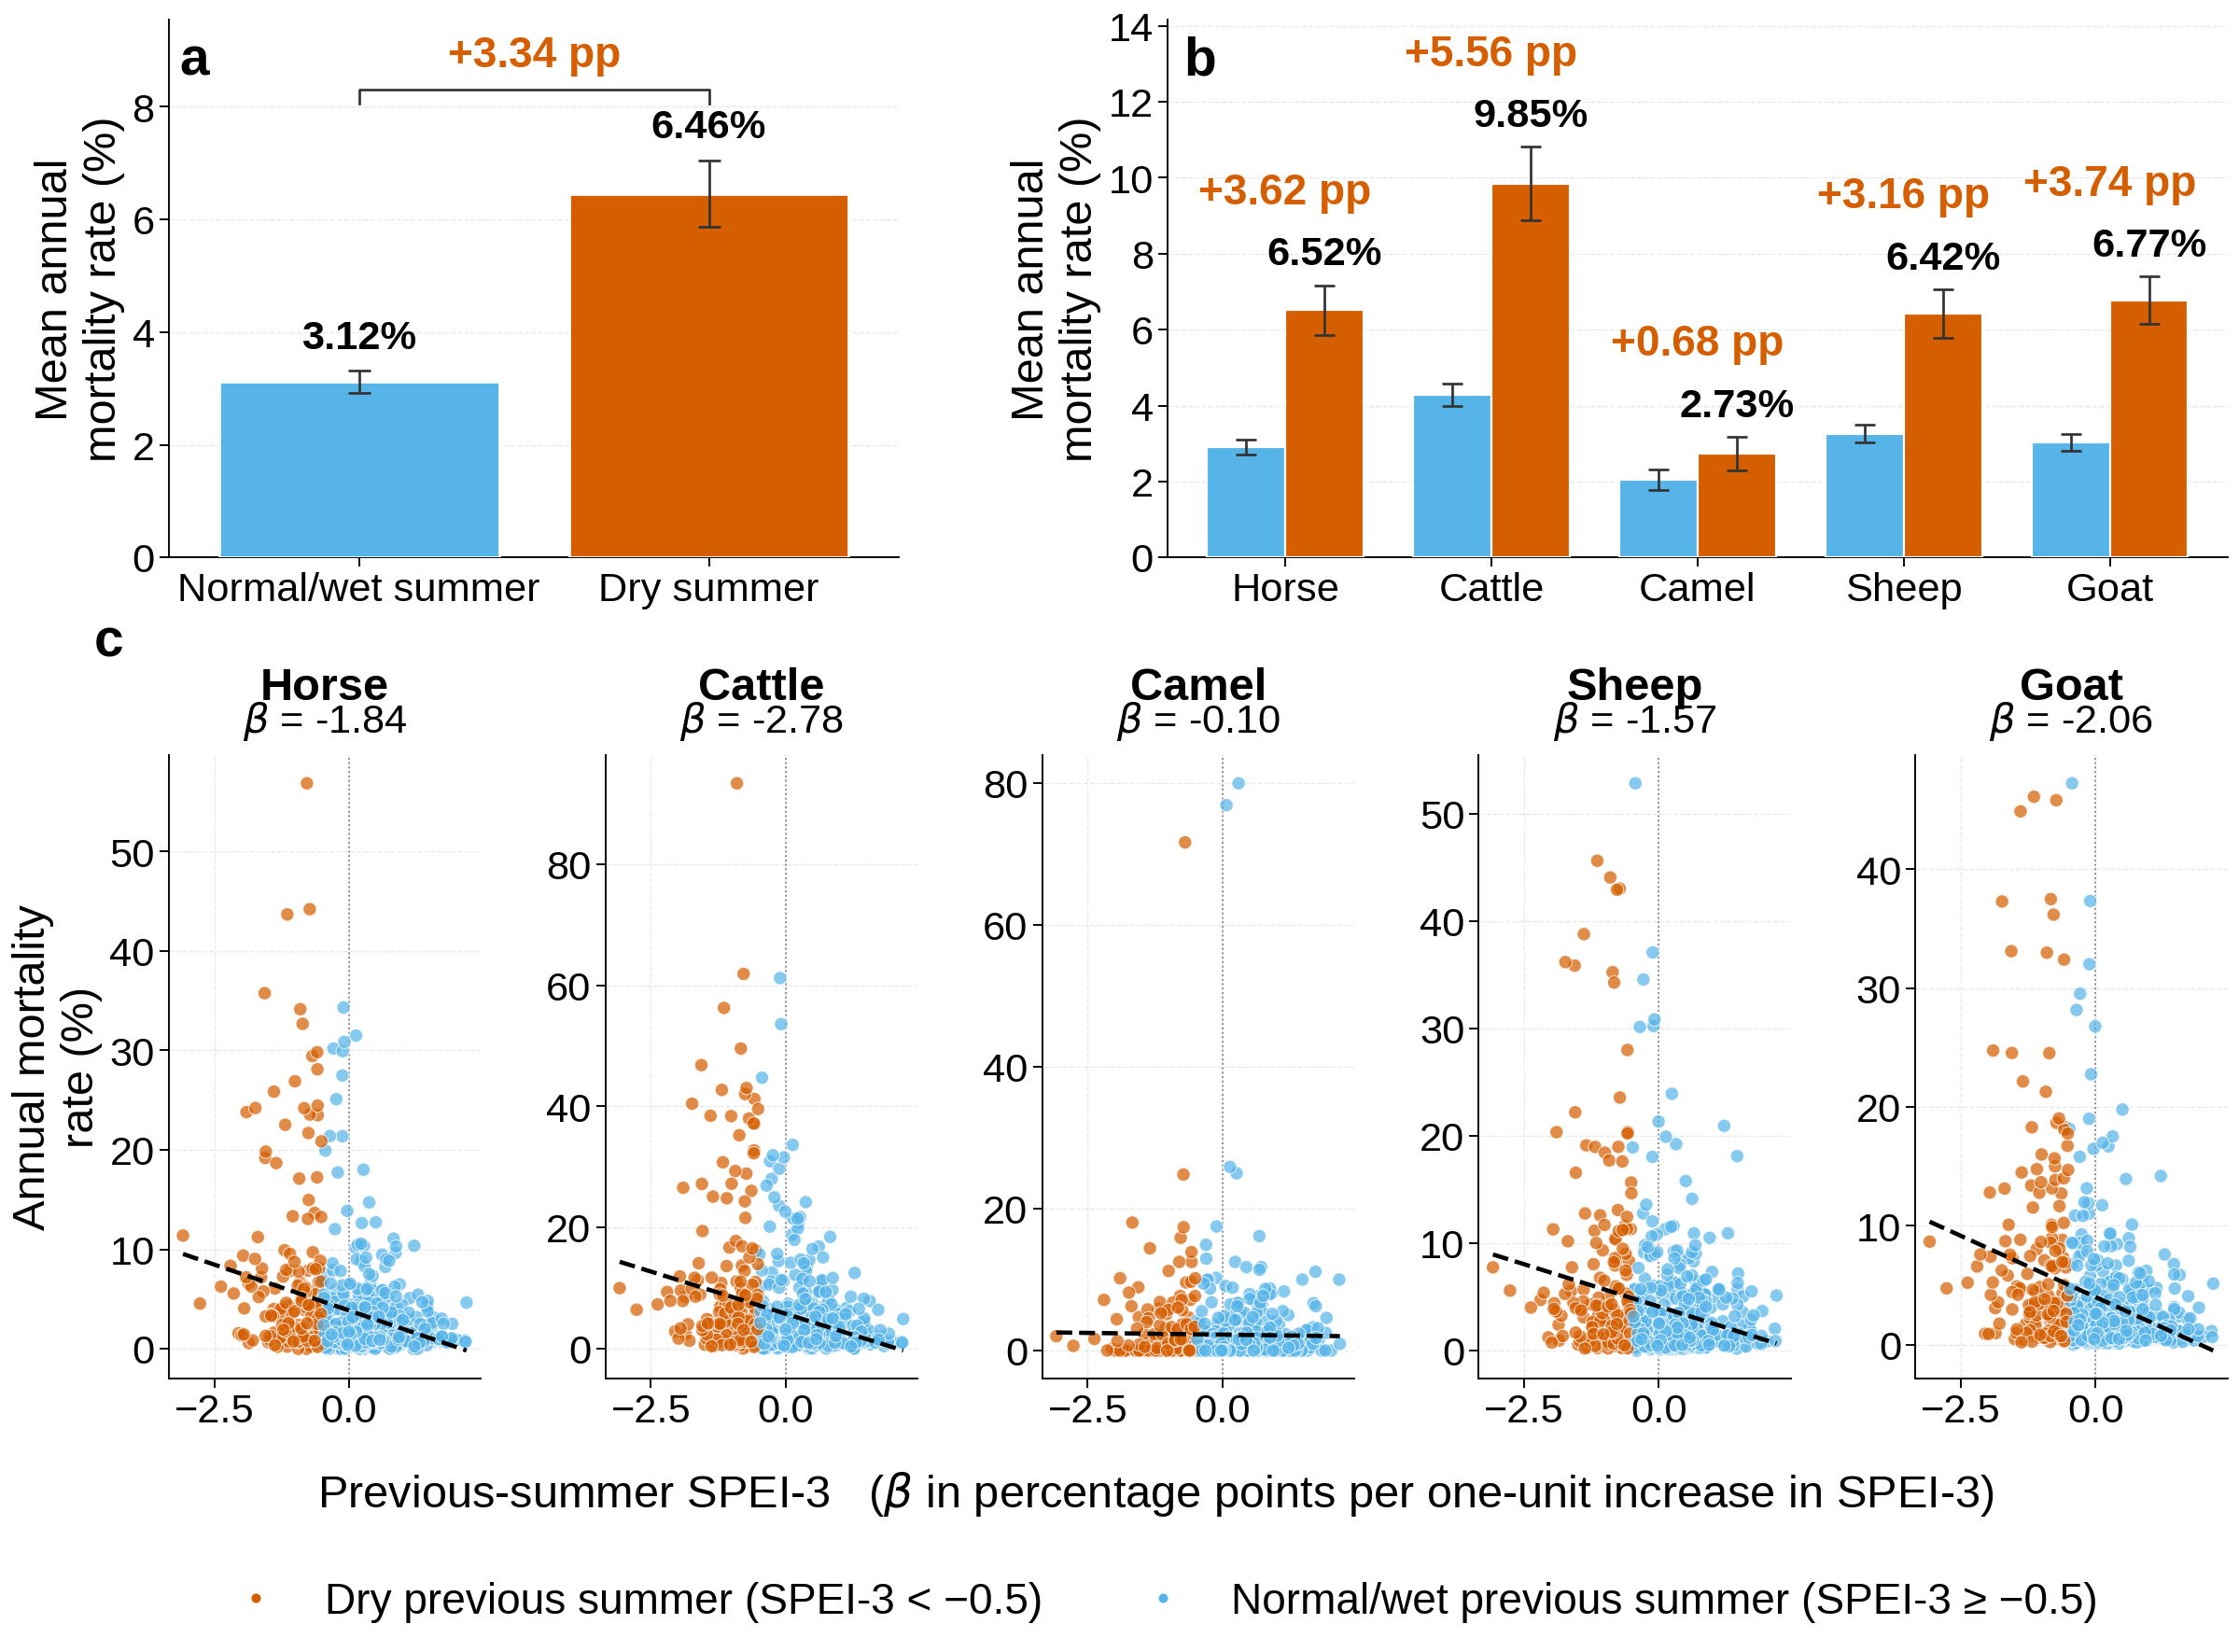

Panel (c) slopes, percentage points per one-unit increase in SPEI-3
  Cattle  -2.78
  Goat    -2.06
  Horse   -1.84
  Sheep   -1.57
  Camel   -0.10


In [ ]:
FIG7_SCALE = 3.0
DECIMALS = 2

with mpl.rc_context({"font.size": 8 * FIG7_SCALE,
                     "axes.labelsize": 9 * FIG7_SCALE,
                     "axes.titlesize": 9 * FIG7_SCALE,
                     "xtick.labelsize": 8 * FIG7_SCALE,
                     "ytick.labelsize": 8 * FIG7_SCALE,
                     "legend.fontsize": 8 * FIG7_SCALE,
                     "axes.linewidth": 0.35 * FIG7_SCALE,
                     "pdf.fonttype": 42, "ps.fonttype": 42}):

    fig = plt.figure(
        figsize=(dl.AGU_MAX_WIDTH_IN * FIG7_SCALE, 4.85 * FIG7_SCALE),
        facecolor="white")
    outer = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[1.0, 1.16], hspace=0.34)
    top = outer[0].subgridspec(nrows=1, ncols=2, width_ratios=[1.02, 1.48], wspace=0.30)
    bottom = outer[1].subgridspec(nrows=1, ncols=5, wspace=0.40)

    ax_a = fig.add_subplot(top[0])
    ax_b = fig.add_subplot(top[1])
    scatter_axes = [fig.add_subplot(bottom[i]) for i in range(5)]

    aggregate_means = [aggregate_normal.mean(), aggregate_dry.mean()]
    aggregate_errors = [aggregate_normal.sem(), aggregate_dry.sem()]
    aggregate_difference = (round(aggregate_means[1], DECIMALS)
                            - round(aggregate_means[0], DECIMALS))

    bars = ax_a.bar([0, 1], aggregate_means, yerr=aggregate_errors,
                    color=[dl.NORMAL_COLOR, dl.DRY_COLOR], edgecolor="white",
                    linewidth=0.5 * FIG7_SCALE, capsize=2.3 * FIG7_SCALE,
                    error_kw={"linewidth": 0.5 * FIG7_SCALE,
                              "capthick": 0.5 * FIG7_SCALE, "ecolor": "#333333"},
                    zorder=3)

    aggregate_top = max(m + e for m, e in zip(aggregate_means, aggregate_errors))
    padding = max(0.25, aggregate_top * 0.035)

    for bar, mean, error in zip(bars, aggregate_means, aggregate_errors):
        ax_a.text(bar.get_x() + bar.get_width() / 2, mean + error + padding,
                  f"{mean:.{DECIMALS}f}%", ha="center", va="bottom",
                  fontsize=8 * FIG7_SCALE, fontweight="bold")

    bracket_y = aggregate_top + padding * 5
    ax_a.plot([0, 0, 1, 1],
              [bracket_y - padding, bracket_y, bracket_y, bracket_y - padding],
              color="#333333", linewidth=0.5 * FIG7_SCALE, clip_on=False)
    ax_a.text(0.5, bracket_y + padding, f"{aggregate_difference:+.{DECIMALS}f} pp",
              ha="center", va="bottom", fontsize=8.5 * FIG7_SCALE,
              fontweight="bold", color=dl.DRY_COLOR)

    ax_a.set_ylabel("Mean annual\nmortality rate (%)",
                    fontsize=9 * FIG7_SCALE, labelpad=4)
    ax_a.set_xticks([0, 1], ["Normal/wet summer", "Dry summer"])
    ax_a.set_ylim(0, bracket_y + padding * 5)
    ax_a.margins(x=0.08)
    ax_a.text(0.015, 0.97, "a", transform=ax_a.transAxes,
              fontsize=10.5 * FIG7_SCALE, fontweight="bold", ha="left", va="top",
              zorder=10)

    positions = np.arange(len(dl.SPECIES_COLS))
    bar_width = 0.38
    ordered = table_s7.set_index("Column").loc[dl.SPECIES_COLS]

    ax_b.bar(positions - bar_width / 2, ordered["Normal_mean"], bar_width,
             yerr=ordered["Normal_se"], color=dl.NORMAL_COLOR, edgecolor="white",
             linewidth=0.4 * FIG7_SCALE, capsize=2 * FIG7_SCALE,
             error_kw={"linewidth": 0.5 * FIG7_SCALE,
                       "capthick": 0.5 * FIG7_SCALE, "ecolor": "#333333"}, zorder=3)
    ax_b.bar(positions + bar_width / 2, ordered["Dry_mean"], bar_width,
             yerr=ordered["Dry_se"], color=dl.DRY_COLOR, edgecolor="white",
             linewidth=0.4 * FIG7_SCALE, capsize=2 * FIG7_SCALE,
             error_kw={"linewidth": 0.5 * FIG7_SCALE,
                       "capthick": 0.5 * FIG7_SCALE, "ecolor": "#333333"}, zorder=3)

    species_top = float(np.nanmax(np.concatenate([
        (ordered["Normal_mean"] + ordered["Normal_se"]).to_numpy(),
        (ordered["Dry_mean"] + ordered["Dry_se"]).to_numpy()])))
    species_padding = max(0.30, species_top * 0.030)
    species_gap = max(0.85, species_top * 0.11)

    for index, column in enumerate(dl.SPECIES_COLS):
        row = ordered.loc[column]
        ax_b.text(positions[index] + bar_width / 2,
                  row["Dry_mean"] + row["Dry_se"] + species_padding,
                  f"{row['Dry_mean']:.{DECIMALS}f}%", ha="center", va="bottom",
                  fontsize=8 * FIG7_SCALE, fontweight="bold")
        pair_top = max(row["Normal_mean"] + row["Normal_se"],
                       row["Dry_mean"] + row["Dry_se"])
        shown_difference = (round(row["Dry_mean"], DECIMALS)
                            - round(row["Normal_mean"], DECIMALS))
        ax_b.text(positions[index], pair_top + species_gap + species_padding * 2.2,
                  f"{shown_difference:+.{DECIMALS}f} pp", ha="center", va="bottom",
                  fontsize=8.5 * FIG7_SCALE, color=dl.DRY_COLOR, fontweight="bold")

    ax_b.set_ylabel("Mean annual\nmortality rate (%)",
                    fontsize=9 * FIG7_SCALE, labelpad=4)
    ax_b.set_xticks(positions, [dl.SPECIES_LABELS[c] for c in dl.SPECIES_COLS])
    ax_b.set_ylim(0, species_top + species_gap + species_top * 0.20)
    ax_b.yaxis.set_major_locator(MultipleLocator(2))
    ax_b.margins(x=0.04)
    ax_b.text(0.015, 0.97, "b", transform=ax_b.transAxes,
              fontsize=10.5 * FIG7_SCALE, fontweight="bold", ha="left", va="top",
              zorder=10)

    slopes = {}
    for axis, column in zip(scatter_axes, dl.SPECIES_COLS):
        subset = plot_panel.dropna(subset=["SPEI_PrevSummer", column])
        x_values = subset["SPEI_PrevSummer"].to_numpy()
        y_values = subset[column].to_numpy() * 100
        colors = np.where(subset["Dry_PrevSummer"], dl.DRY_COLOR, dl.NORMAL_COLOR)

        axis.scatter(x_values, y_values, c=colors, s=7 * FIG7_SCALE ** 2, alpha=0.72,
                     edgecolors="white", linewidths=0.2 * FIG7_SCALE, zorder=3)

        slope, intercept = np.polyfit(x_values, y_values, 1)
        slopes[column] = slope
        trend_x = np.linspace(x_values.min(), x_values.max(), 100)
        axis.plot(trend_x, intercept + slope * trend_x, color="black",
                  linewidth=0.85 * FIG7_SCALE, linestyle="--", zorder=4)
        axis.axvline(0, color="gray", linewidth=0.33 * FIG7_SCALE,
                     linestyle=":", zorder=1)

        axis.set_title(dl.SPECIES_LABELS[column], fontsize=9 * FIG7_SCALE,
                       fontweight="bold", pad=11 * FIG7_SCALE)
        axis.text(0.5, 1.02, rf"$\beta$ = {slope:.2f}",
                  transform=axis.transAxes, fontsize=8 * FIG7_SCALE,
                  ha="center", va="bottom")

    scatter_axes[0].set_ylabel("Annual mortality\nrate (%)",
                               fontsize=9 * FIG7_SCALE, labelpad=4)
    scatter_axes[0].text(-0.24, 1.14, "c", transform=scatter_axes[0].transAxes,
                         fontsize=10.5 * FIG7_SCALE, fontweight="bold",
                         ha="left", va="bottom")

    for axis in [ax_a, ax_b] + scatter_axes:
        axis.grid(linestyle="--", linewidth=0.25 * FIG7_SCALE, alpha=0.28, zorder=0)
        axis.set_axisbelow(True)
        axis.spines[["top", "right"]].set_visible(False)
        axis.tick_params(axis="both", labelsize=8 * FIG7_SCALE,
                         width=0.35 * FIG7_SCALE, length=1.8 * FIG7_SCALE, pad=3)
    for axis in (ax_a, ax_b):
        axis.grid(axis="x", visible=False)

    fig.text(0.5, 0.105, "Previous-summer SPEI-3   "
             r"($\beta$ in percentage points per one-unit increase in SPEI-3)",
             ha="center", va="center", fontsize=9 * FIG7_SCALE)

    legend_handles = [
        Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=dl.DRY_COLOR,
               markeredgecolor="white", markersize=2.2 * FIG7_SCALE,
               label="Dry previous summer (SPEI-3 < \u22120.5)"),
        Line2D([0], [0], marker="o", linestyle="none", markerfacecolor=dl.NORMAL_COLOR,
               markeredgecolor="white", markersize=2.2 * FIG7_SCALE,
               label="Normal/wet previous summer (SPEI-3 \u2265 \u22120.5)"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, 0.010),
               ncol=2, fontsize=8.5 * FIG7_SCALE, frameon=False,
               columnspacing=1.8, handletextpad=0.6)

    fig.subplots_adjust(top=0.94, bottom=0.17, left=0.095, right=0.94)

dl.save_figure(fig, "figure_07_drought_and_species_mortality", scale=FIG7_SCALE)
plt.show()

print("Panel (c) slopes, percentage points per one-unit increase in SPEI-3")
for column, slope in sorted(slopes.items(), key=lambda item: item[1]):
    print(f"  {dl.SPECIES_LABELS[column]:7s} {slope:+.2f}")

In [ ]:
print("Largest annual loss years")
losses = losses_annual.set_index("Year")
for year, value in losses["Total"].nlargest(6).items():
    prior = population_total.loc[population_total["Year"].eq(year - 1),
                                 "Population_millions"]
    prior = prior.values[0] if len(prior) else np.nan
    rate = national_mortality.loc[national_mortality["Year"].eq(year), "All_SFU_pct"]
    rate = rate.values[0] if len(rate) else np.nan
    print(f"  {int(year)}: {value:5.2f} M lost | prior herd {prior:5.1f} M "
          f"| {value / prior * 100:4.1f}% of herd | aimag-mean SFU rate {rate:5.2f}%")

Largest annual loss years
  2010: 10.25 M lost | prior herd  44.0 M | 23.3% of herd | aimag-mean SFU rate 19.25%
  2024:  9.33 M lost | prior herd  64.7 M | 14.4% of herd | aimag-mean SFU rate 12.71%
  2023:  4.88 M lost | prior herd  71.1 M |  6.9% of herd | aimag-mean SFU rate  5.80%
  2001:  4.73 M lost | prior herd  30.2 M | 15.7% of herd | aimag-mean SFU rate 18.96%
  2000:  3.48 M lost | prior herd  33.6 M | 10.4% of herd | aimag-mean SFU rate 10.51%
  2021:  3.00 M lost | prior herd  67.1 M |  4.5% of herd | aimag-mean SFU rate  3.87%
